In [16]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow.keras import layers
from tensorflow.keras.layers import Embedding,Dense
from tensorflow.keras import Sequential
from sklearn.metrics import r2_score
import pandas as pd
import keras
from keras import backend as K
print(tf.__version__)

2.15.0


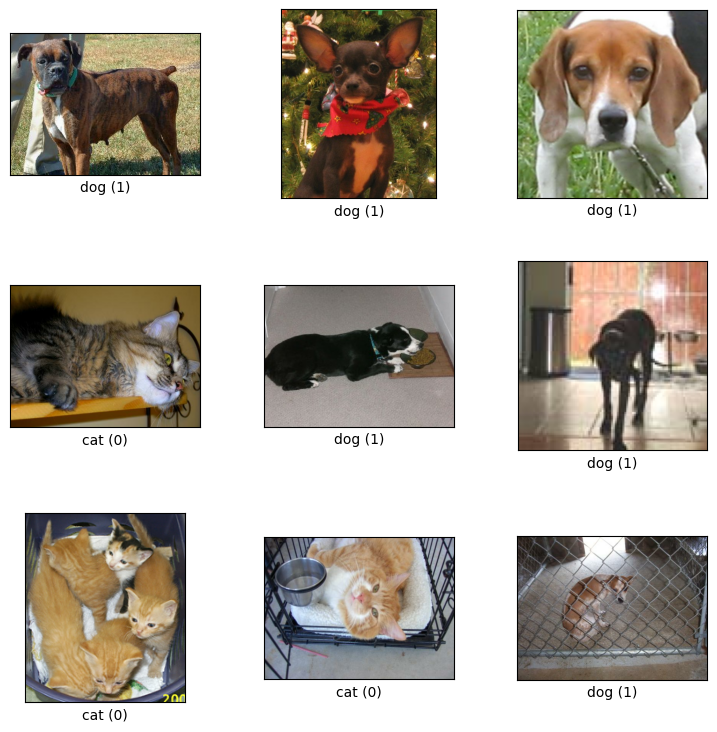

In [3]:
(ds_train_mnist, ds_test_mnist), ds_info = tfds.load(
    name = 'cats_vs_dogs',
    split=['train[:20%]', 'train[20%:30%]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True)
fig = tfds.show_examples(ds_train_mnist, ds_info)

In [4]:
label_names = ds_info.features['label'].names

In [5]:
def augment_data(images, labels):
    images = tf.image.resize(images,(128,128))
    images = tf.image.random_flip_left_right(images)
    images = tf.image.rot90(images)
    images = tf.image.random_brightness(images, 0.2)
    images = tf.image.random_contrast(images, 0.5, 2.0)
    images = tf.image.random_saturation(images, 0.75, 1.25)
    return tf.cast(images, tf.float32) / 255., labels

def data_load(data_ds,augmented=augment_data,shuffle_=True ,batch_=5):
    data_ds = data_ds.map(
        augmented, num_parallel_calls=tf.data.AUTOTUNE)
    data_ds = data_ds.cache()
    if shuffle_:
        data_ds = data_ds.shuffle(len(data_ds))
    data_ds = data_ds.batch(batch_)
    data_ds = data_ds.prefetch(tf.data.AUTOTUNE)
    return data_ds

In [7]:
data_train = data_load(ds_train_mnist)
data_test = data_load(ds_test_mnist,shuffle_=False)
for ds,lb in data_train.take(1):
    shaped=list(ds.shape)
shaped

[5, 128, 128, 3]

In [9]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=shaped[1:]),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(2,activation='softmax')
])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 49152)             0         
                                                                 
 dense_2 (Dense)             (None, 64)                3145792   
                                                                 
 dense_3 (Dense)             (None, 2)                 130       
                                                                 
Total params: 3145922 (12.00 MB)
Trainable params: 3145922 (12.00 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

In [11]:
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min")
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min' ,factor=0.4,
                              patience=5, min_lr=1e-7,verbose=1)
directory_files='carpeta_resultados_clase/'
def scheduler(epoch, lr):
      if epoch%10 != 0:
        return lr
      else:
        return lr * tf.math.exp(-0.1)
callback_Scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose=1)

checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=directory_files+'model.{epoch:02d}-{val_loss:.2f}.h5',
                                               verbose=1,
                                               save_best_only=True)
tensorboard =tf.keras.callbacks.TensorBoard(log_dir=directory_files+'logs', histogram_freq=1),

callbacks=[tensorboard, checkpoint,early_callback,callback_Scheduler]


history= model.fit(
    data_train,
    epochs=6,
    validation_data=data_test,
    callbacks=callbacks,
    verbose=1)


Epoch 1: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 1/6



931/931 [==============================] - ETA: 0s - loss: 0.7983 - accuracy: 0.5026
Epoch 1: val_loss improved from inf to 0.69332, saving model to carpeta_resultados_clase\model.01-0.69.h5
931/931 [==============================] - 26s 27ms/step - loss: 0.7983 - accuracy: 0.5026 - val_loss: 0.6933 - val_accuracy: 0.4912 - lr: 9.0484e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 2/6
  3/931 [..............................] - ETA: 24s - loss: 0.6903 - accuracy: 0.6667

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


930/931 [============================>.] - ETA: 0s - loss: 0.6933 - accuracy: 0.5022
Epoch 2: val_loss improved from 0.69332 to 0.69303, saving model to carpeta_resultados_clase\model.02-0.69.h5
931/931 [==============================] - 25s 27ms/step - loss: 0.6933 - accuracy: 0.5021 - val_loss: 0.6930 - val_accuracy: 0.5088 - lr: 9.0484e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 3/6
931/931 [==============================] - ETA: 0s - loss: 0.6933 - accuracy: 0.4837
Epoch 3: val_loss improved from 0.69303 to 0.69301, saving model to carpeta_resultados_clase\model.03-0.69.h5
931/931 [==============================] - 24s 26ms/step - loss: 0.6933 - accuracy: 0.4837 - val_loss: 0.6930 - val_accuracy: 0.5088 - lr: 9.0484e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 4/6
929/931 [============================>.] - ETA: 0s - loss: 0.6933 - accuracy: 0.5005
Epoch 4: val_loss did not improve from 0.6930

In [12]:
model.evaluate(data_test)

466/466 [==============================] - 3s 6ms/step - loss: 0.6931 - accuracy: 0.5088


[0.6931008100509644, 0.5088096261024475]

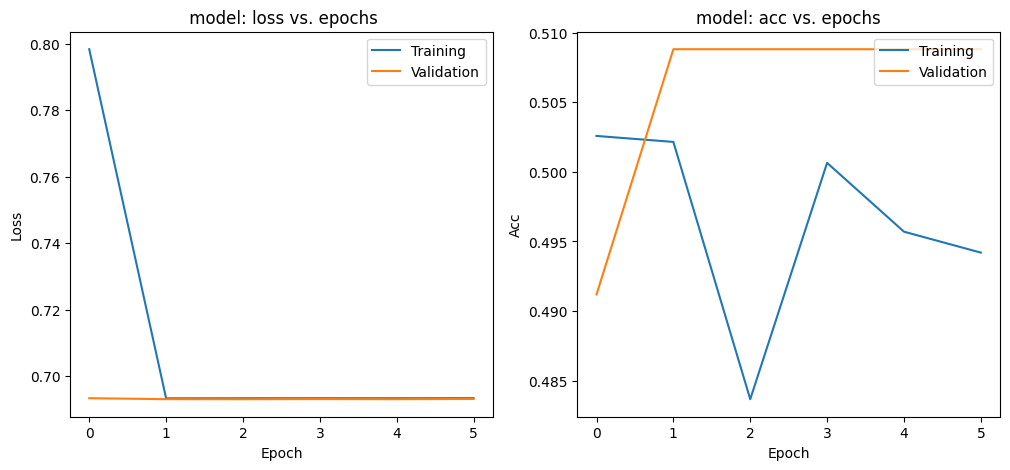

In [13]:
fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title(' model: loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

In [14]:
def show_confusion_matrix(cm, labels):
  plt.figure(figsize=(10, 8))
  sns.heatmap(cm, xticklabels=labels, yticklabels=labels, 
              annot=True, fmt='g')
  plt.xlabel('Prediction')
  plt.ylabel('Label')
  plt.show()

1/1 [==============================] - 0s 28ms/step


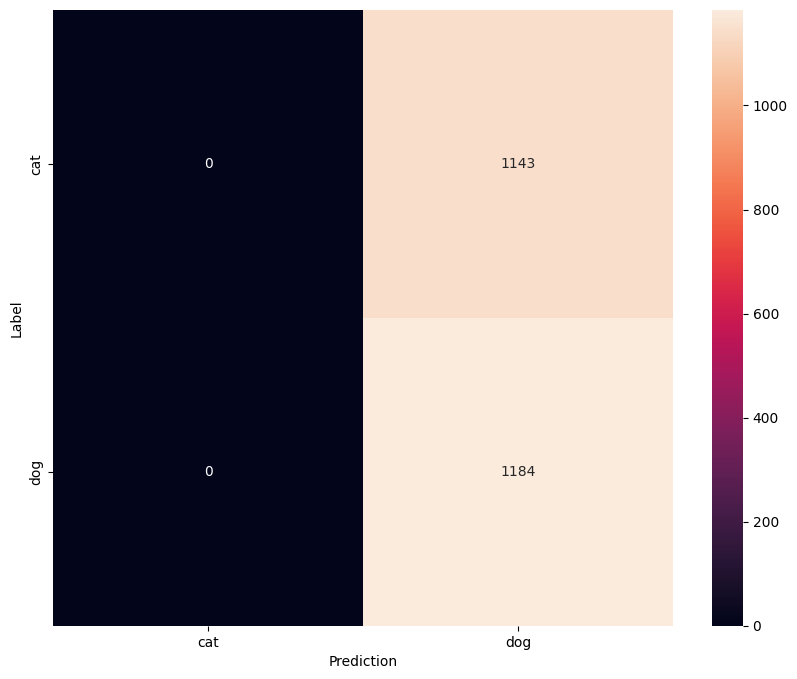

In [18]:
pred=[]
lab=[]
for ds, lb in data_test:
    pred.append(tf.math.argmax(model.predict(ds),axis=1))
    lab.append(lb)
confusion_mtx = tf.math.confusion_matrix(
    np.concatenate(lab),
    np.concatenate(pred),
    num_classes=len(label_names))
show_confusion_matrix(confusion_mtx, label_names)

In [19]:
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dropout,Dense
modelcnn = Sequential()
modelcnn.add(Conv2D(16,activation='relu' , strides=(1, 1),kernel_size=(5,5),padding='same', input_shape=shaped[1:]))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))
modelcnn.add(Conv2D(32,activation='relu',  strides=(1, 1),kernel_size=(3,3),padding='same'))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))
modelcnn.add(Conv2D(32,activation='relu',  strides=(1, 1),kernel_size=(3,3),padding='same'))
modelcnn.add(MaxPooling2D(pool_size=(2, 2)))

# Flattening the 2D arrays for fully connected layers
modelcnn.add(Flatten()) 
#modelcnn.add(tf.keras.layers.GlobalAveragePooling2D())
modelcnn.add(Dense(128, activation=tf.nn.relu))
modelcnn.add(Dropout(0.2))
modelcnn.add(Dense(2,activation=tf.nn.softmax))
modelcnn.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 16)      1216      
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 16)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)       

In [20]:
modelcnn.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'])

In [21]:
directory_files='carpeta_resultados_clasecnn/'

In [22]:

early_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min")
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min' ,factor=0.4,
                              patience=5, min_lr=1e-7,verbose=1)

def scheduler(epoch, lr):
      if epoch%10 != 0:
        return lr
      else:
        return lr * tf.math.exp(-0.1)
callback_Scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler,verbose=1)

checkpoint = tf.keras.callbacks.ModelCheckpoint(filepath=directory_files+'model.{epoch:02d}-{val_loss:.2f}.h5',
                                               verbose=1,
                                               save_best_only=True)
tensorboard =tf.keras.callbacks.TensorBoard(log_dir=directory_files+'logs', histogram_freq=1),

callbacks=[tensorboard, checkpoint,early_callback,callback_Scheduler]


historycnn= modelcnn.fit(
    data_train,
    epochs=6,
    validation_data=data_test,
    callbacks=callbacks,
    verbose=1)


Epoch 1: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 1/6
930/931 [============================>.] - ETA: 0s - loss: 0.6863 - accuracy: 0.5688
Epoch 1: val_loss improved from inf to 0.66481, saving model to carpeta_resultados_clasecnn\model.01-0.66.h5
931/931 [==============================] - 23s 23ms/step - loss: 0.6863 - accuracy: 0.5688 - val_loss: 0.6648 - val_accuracy: 0.6175 - lr: 9.0484e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 2/6
  1/931 [..............................] - ETA: 30s - loss: 0.5267 - accuracy: 0.8000

c:\Users\javier\miniconda3\envs\tfnew\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


931/931 [==============================] - ETA: 0s - loss: 0.6566 - accuracy: 0.6191
Epoch 2: val_loss improved from 0.66481 to 0.63413, saving model to carpeta_resultados_clasecnn\model.02-0.63.h5
931/931 [==============================] - 21s 22ms/step - loss: 0.6566 - accuracy: 0.6191 - val_loss: 0.6341 - val_accuracy: 0.6407 - lr: 9.0484e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 3/6
929/931 [============================>.] - ETA: 0s - loss: 0.6111 - accuracy: 0.6626
Epoch 3: val_loss did not improve from 0.63413
931/931 [==============================] - 21s 23ms/step - loss: 0.6112 - accuracy: 0.6627 - val_loss: 0.6409 - val_accuracy: 0.6386 - lr: 9.0484e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0009048374486155808.
Epoch 4/6
930/931 [============================>.] - ETA: 0s - loss: 0.5548 - accuracy: 0.7144
Epoch 4: val_loss did not improve from 0.63413
931/931 [==============================] - 21s 23ms/step -

In [23]:
modelcnn.evaluate(data_test)

466/466 [==============================] - 3s 6ms/step - loss: 0.7161 - accuracy: 0.7065


[0.7161263823509216, 0.7064890265464783]

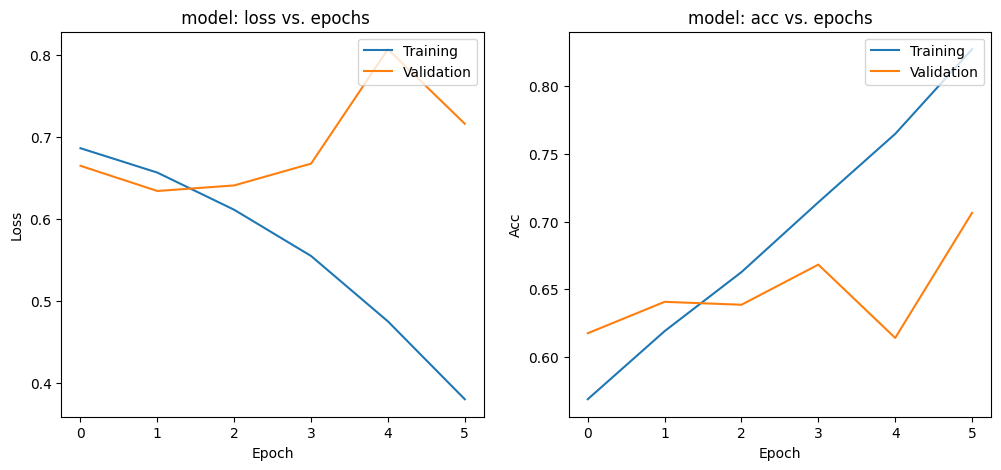

In [25]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 5))

fig.add_subplot(121)

plt.plot(historycnn.history['loss'])
plt.plot(historycnn.history['val_loss'])
plt.title(' model: loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(historycnn.history['accuracy'])
plt.plot(historycnn.history['val_accuracy'])
plt.title('model: acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

(<matplotlib.image.AxesImage at 0x247cae48c40>,
 <tf.Tensor: shape=(), dtype=int64, numpy=0>)

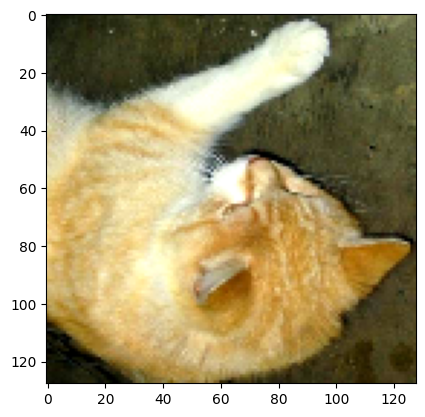

In [29]:
plt.imshow(ds[0]),lb[0]

In [30]:
successive_outputs = [layer.output for layer in modelcnn.layers[1:]]
visualization_model = tf.keras.models.Model(inputs = modelcnn.input, outputs = successive_outputs)



In [31]:
successive_feature_maps = visualization_model.predict(tf.expand_dims(ds[0],axis=0))

1/1 [==============================] - 0s 168ms/step


In [32]:
layer_names = [layer.name for layer in modelcnn.layers]

(1, 64, 64, 16)
(1, 64, 64, 32)
(1, 32, 32, 32)
(1, 32, 32, 32)
(1, 16, 16, 32)
(1, 8192)
(1, 128)
(1, 128)
(1, 2)


C:\Users\javier\AppData\Local\Temp\ipykernel_21676\2756211480.py:20: RuntimeWarning: invalid value encountered in divide
  x /= x.std ()
C:\Users\javier\AppData\Local\Temp\ipykernel_21676\2756211480.py:23: RuntimeWarning: invalid value encountered in cast
  x  = np.clip(x, 0, 255).astype('uint8')


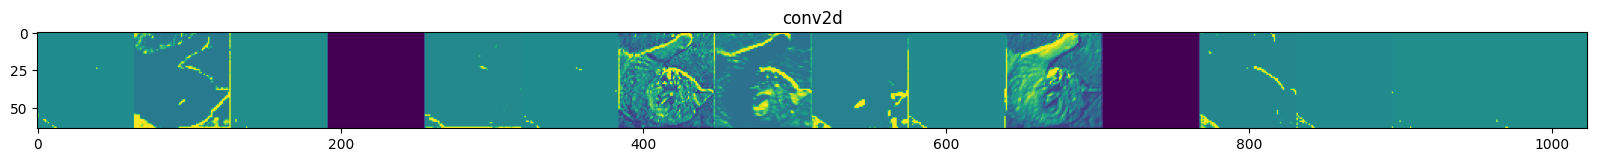

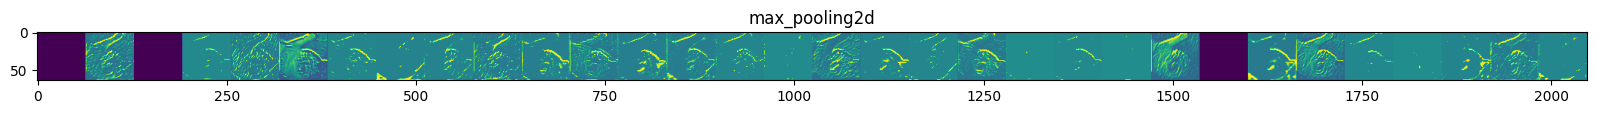

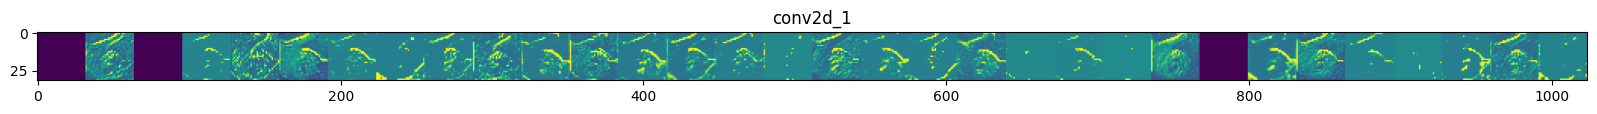

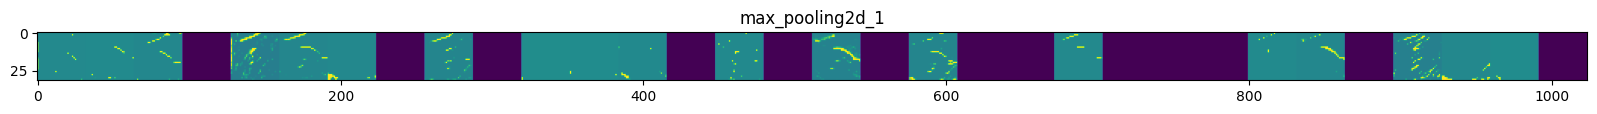

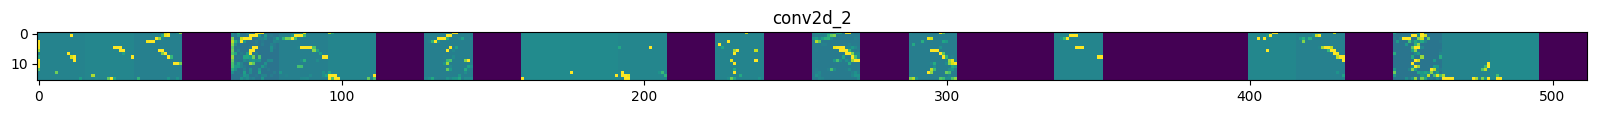

In [33]:
for layer_name, feature_map in zip(layer_names, successive_feature_maps):
  print(feature_map.shape)
  if len(feature_map.shape) == 4:
    
    #-------------------------------------------
    # Just do this for the conv / maxpool layers, not the fully-connected layers
    #-------------------------------------------
    n_features = feature_map.shape[-1]  # number of features in the feature map
    size       = feature_map.shape[ 1]  # feature map shape (1, size, size, n_features)
    
    # We will tile our images in this matrix
    display_grid = np.zeros((size, size * n_features))
    
    #-------------------------------------------------
    # Postprocess the feature to be visually palatable
    #-------------------------------------------------
    for i in range(n_features):
      x  = feature_map[0, :, :, i]
      x -= x.mean()
      x /= x.std ()
      x *=  64
      x += 128
      x  = np.clip(x, 0, 255).astype('uint8')
      display_grid[:, i * size : (i + 1) * size] = x # Tile each filter into a horizontal grid

    #-----------------
    # Display the grid
    #-----------------

    scale = 20. / n_features
    plt.figure( figsize=(scale * n_features, scale) )
    plt.title ( layer_name )
    plt.grid  ( False )
    plt.imshow( display_grid, aspect='auto', cmap='viridis' ) 

In [35]:
df = pd.read_csv('Sunspots_.csv', index_col=0)
df.head()

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7


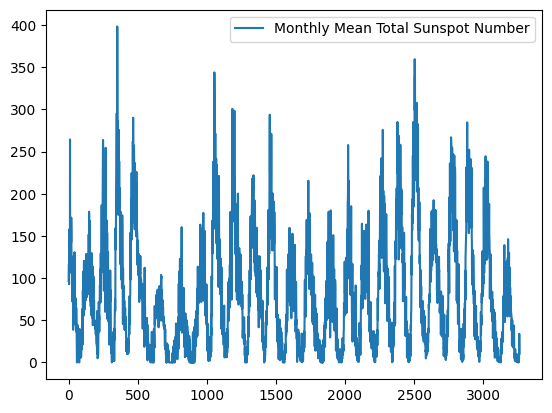

In [36]:
df.plot()
plt.show()

In [37]:
time_index = np.array(df['Date'])
data = np.array(df['Monthly Mean Total Sunspot Number'])
print(time_index.shape)
print(data.shape)

(3265,)
(3265,)


In [38]:
##Hiperparametros
SPLIT_TEST_TRAIN = 0.8
WINDOW_SIZE = 60
BATCH_SIZE = 32
SHUFFLE_BUFFER = 1000

In [39]:
split_index = int(SPLIT_TEST_TRAIN * data.shape[0])
print(split_index)

2612


In [40]:
train_data = data[:split_index]
train_time = time_index[:split_index]

test_data = data[split_index:]
test_time = time_index[split_index:]

In [41]:
def ts_data_timeseries(data, window_size, batch_size):
  
  ds = tf.data.Dataset.from_tensor_slices(data)
  ds = ds.window(window_size + 1, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda window: window.batch(window_size + 1))
  ds = ds.map(lambda window: (window[:-1], window[-1]))
  ds = ds.batch(batch_size).prefetch(1)
  return ds



In [42]:
train_dataset = ts_data_timeseries(train_data, WINDOW_SIZE, BATCH_SIZE)
test_dataset = ts_data_timeseries(test_data, WINDOW_SIZE, BATCH_SIZE)

In [43]:
 for ds in train_dataset.take(1):
        print(ds)

(<tf.Tensor: shape=(32, 60), dtype=float64, numpy=
array([[ 96.7, 104.3, 116.7, ...,  41.7,  33.3,  11.2],
       [104.3, 116.7,  92.8, ...,  33.3,  11.2,   0. ],
       [116.7,  92.8, 141.7, ...,  11.2,   0. ,   5. ],
       ...,
       [ 84.5, 110.5,  99.7, ...,   9. ,  15.7,  20.8],
       [110.5,  99.7,  39.2, ...,  15.7,  20.8,  21.5],
       [ 99.7,  39.2,  38.7, ...,  20.8,  21.5,   6. ]])>, <tf.Tensor: shape=(32,), dtype=float64, numpy=
array([ 0. ,  5. ,  2.8, 22.8, 34.5, 44.5, 31.3, 20.5, 13.7, 40.2, 22. ,
        7. , 17. , 18.7, 11.3, 10.8,  0. ,  0. , 14.3,  5.3, 29.7, 39.5,
       11.3, 33.3, 20.8, 11.8,  9. , 15.7, 20.8, 21.5,  6. , 10.7])>)


In [51]:
def plots_pred(model, data, test_data, conv=True):
    forecast=[]
    for time in range(split_index-WINDOW_SIZE,len(data) - WINDOW_SIZE):
      forecast.append(model.predict(data[time:time + WINDOW_SIZE][np.newaxis]))

    forecast = forecast[:]
    results = np.array(forecast)[:, 0, 0]
    if conv:
        results= np.squeeze(results)

    error_test = tf.keras.metrics.mean_absolute_error(test_data, results).numpy()
    plt.figure(figsize=(15, 6))

    plt.plot(list(range(split_index,len(data))), test_data, label = 'Test Data')
    plt.plot(list(range(split_index,len(data))), results, label = 'Predictions')
    plt.fill_between(range(split_index,len(data)), results - error_test, results + error_test, alpha = 0.3, color = 'grey',label=r'error 1-$\sigma$')
    plt.legend()
    plt.show()

In [52]:
modelcnn = keras.models.Sequential()
modelcnn.add(keras.layers.InputLayer(input_shape=[WINDOW_SIZE]))
modelcnn.add(keras.layers.Lambda(
       lambda inputs: tf.expand_dims(inputs,axis=0)))
for _ in range(3):
    modelcnn.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu"))
modelcnn.add(keras.layers.Conv1D(filters=1, kernel_size=1))
modelcnn.summary()
modelcnn.compile(loss="mse", optimizer="adam", metrics=['mse'])
historycnn = modelcnn.fit(train_dataset, epochs=20,
                    validation_data=test_dataset)


Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda_3 (Lambda)           (1, None, 60)             0         
                                                                 
 conv1d_22 (Conv1D)          (1, None, 20)             2420      
                                                                 
 conv1d_23 (Conv1D)          (1, None, 20)             820       
                                                                 
 conv1d_24 (Conv1D)          (1, None, 20)             820       
                                                                 
 conv1d_25 (Conv1D)          (1, None, 1)              21        
                                                                 
Total params: 4081 (15.94 KB)
Trainable params: 4081 (15.94 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
80/80 [==

1/1 [==============================] - 0s 59ms/step


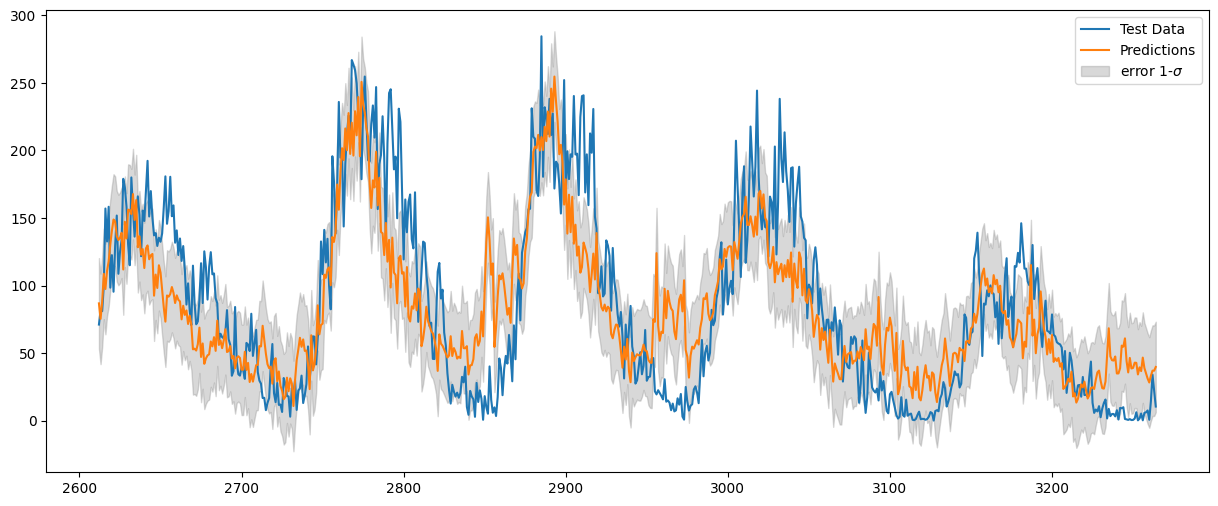

In [53]:
plots_pred(modelcnn, data, test_data)

In [54]:
modelwavelet = keras.models.Sequential()
modelwavelet.add(keras.layers.InputLayer(input_shape=[WINDOW_SIZE]))
modelwavelet.add(keras.layers.Lambda(
       lambda inputs: tf.expand_dims(inputs,axis=0)))
for rate in (1, 2, 4, 8) * 2:
    modelwavelet.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
                                  activation="relu", dilation_rate=rate))
modelwavelet.add(keras.layers.Conv1D(filters=1, kernel_size=1))
modelwavelet.compile(loss="mse", optimizer="adam", metrics=['mse'])
history = modelwavelet.fit(train_dataset, epochs=30,
                    validation_data=test_dataset)

Epoch 1/30
80/80 [==============================] - 6s 27ms/step - loss: 5780.2925 - mse: 5780.2925 - val_loss: 3106.3308 - val_mse: 3106.3308
Epoch 2/30
80/80 [==============================] - 1s 17ms/step - loss: 2425.1123 - mse: 2425.1123 - val_loss: 2074.1919 - val_mse: 2074.1919
Epoch 3/30
80/80 [==============================] - 2s 19ms/step - loss: 2097.3406 - mse: 2097.3406 - val_loss: 1898.6455 - val_mse: 1898.6455
Epoch 4/30
80/80 [==============================] - 1s 19ms/step - loss: 1943.6552 - mse: 1943.6552 - val_loss: 1799.1107 - val_mse: 1799.1107
Epoch 5/30
80/80 [==============================] - 1s 17ms/step - loss: 1884.9583 - mse: 1884.9583 - val_loss: 1780.7300 - val_mse: 1780.7300
Epoch 6/30
80/80 [==============================] - 2s 19ms/step - loss: 1821.4984 - mse: 1821.4984 - val_loss: 1720.4852 - val_mse: 1720.4852
Epoch 7/30
80/80 [==============================] - 1s 18ms/step - loss: 1790.4540 - mse: 1790.4540 - val_loss: 1670.5405 - val_mse: 1670.5405

1/1 [==============================] - 0s 53ms/step


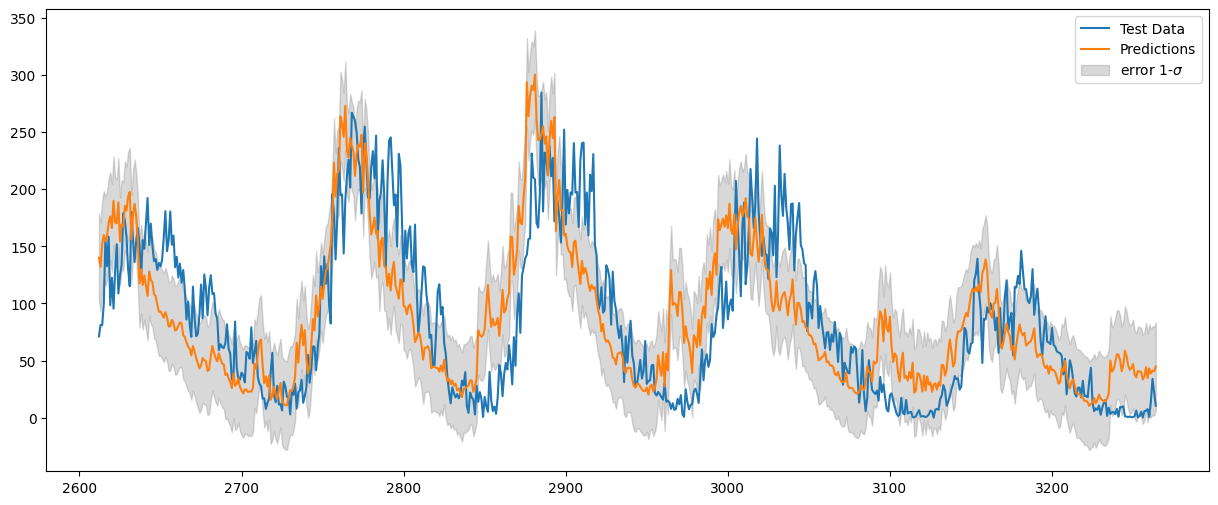

In [55]:
plots_pred(modelwavelet, data, test_data)